In [ ]:
!unzip -q "CK+.zip" -d "./CK+"

replace ./CK+/anger/S010_004_00000017.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
from google.colab import files
files.upload()   # choose CK+.zip


In [ ]:
!ls ./CK+


anger  contempt  disgust  fear	happy  sadness	surprise


In [ ]:
!ls ./CK+


anger  contempt  disgust  fear	happy  sadness	surprise


In [ ]:
!pip install tensorflow keras scikit-learn matplotlib


Found 788 images belonging to 7 classes.
Found 193 images belonging to 7 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 505ms/step - accuracy: 0.2717 - loss: 1.8534 - val_accuracy: 0.2124 - val_loss: 1.8290
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 265ms/step - accuracy: 0.4343 - loss: 1.5339 - val_accuracy: 0.2124 - val_loss: 2.6848
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 250ms/step - accuracy: 0.5368 - loss: 1.2887 - val_accuracy: 0.2124 - val_loss: 3.6747
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 258ms/step - accuracy: 0.5983 - loss: 1.1127 - val_accuracy: 0.2124 - val_loss: 3.5445
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - accuracy: 0.6067 - loss: 1.0904 - val_accuracy: 0.2124 - val_loss: 4.2299
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - accuracy: 0.6621 - loss: 0.9455 - val_accuracy: 0.2124 - val_loss: 5.4750
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - accuracy: 0.6239 - loss: 0.9995 - val_accuracy: 0.2280 - val_loss: 3.7630
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step - accuracy: 0.6754 - loss: 0.8573 - val_accu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


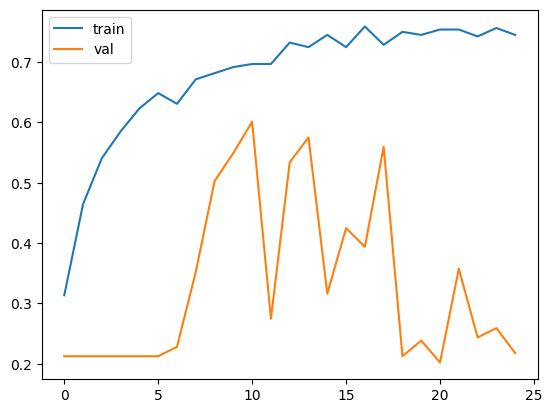

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

data_dir = "./CK+"   # path already correct

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=16,
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=16,
    subset='validation'
)

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers[:-10]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_gen, validation_data=val_gen, epochs=25)

val_loss, val_acc = model.evaluate(val_gen)
print(f"\n✅ Validation Accuracy: {val_acc*100:.2f}%")

Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)
print(classification_report(val_gen.classes, y_pred, target_names=list(val_gen.class_indices.keys())))

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(); plt.show()


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Data setup ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = train_datagen.flow_from_directory(
    './CK+',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    './CK+',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)

# --- Load pretrained VGG16 ---
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze most layers, unfreeze the last 4 convolution blocks
for layer in base_model.layers[:-4]:
    layer.trainable = False

# --- Classification head ---
x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

# --- Compile ---
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Train ---
es = EarlyStopping(patience=5, restore_best_weights=True)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=[es]
)

# --- Evaluate ---
val_loss, val_acc = model.evaluate(val_gen)
print(f"✅ Validation Accuracy: {val_acc*100:.2f}%")


Found 788 images belonging to 7 classes.
Found 193 images belonging to 7 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 228ms/step - accuracy: 0.1722 - loss: 2.0761 - val_accuracy: 0.2694 - val_loss: 1.7790
Epoch 2/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.2390 - loss: 1.9397 - val_accuracy: 0.4145 - val_loss: 1.6810
Epoch 3/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 0.3683 - loss: 1.7182 - val_accuracy: 0.4819 - val_loss: 1.4871
Epoch 4/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.4371 - loss: 1.5605 - val_accuracy: 0.5026 - val_loss: 1.3658
Epoch 5/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.4795 - loss: 1.4461 - val_accuracy: 0.6010 - val_loss: 1.2337
Epoch 6/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.5196 - loss: 1.3428 - val_accuracy: 0.6062 - val_loss: 1.0952
Epoch 7/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.5386 - loss: 1.1698 - val_

In [ ]:
#  IMPORTS
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- DATASET PATH ---
dataset_path = '/content/CK+'  # 👈 your dataset folder

# --- IMAGE AUGMENTATION + VALIDATION SPLIT ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2   # 20% data for validation
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

# --- LOAD PRETRAINED VGG16 BASE ---
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all but last few layers
for layer in base_model.layers[:-8]:
    layer.trainable = False

# --- ADD CUSTOM CLASSIFICATION LAYERS ---
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# --- COMPILE MODEL ---
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# --- CALLBACKS ---
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-6)

# --- TRAIN ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

# --- EVALUATE ---
loss, acc = model.evaluate(val_generator)
print(f"✅ Final Validation Accuracy: {acc * 100:.2f}%")


Found 788 images belonging to 7 classes.
Found 193 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 535ms/step - accuracy: 0.1512 - loss: 2.1155 - val_accuracy: 0.2124 - val_loss: 1.8502 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - accuracy: 0.1977 - loss: 1.8934 - val_accuracy: 0.2539 - val_loss: 1.8151 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 294ms/step - accuracy: 0.2118 - loss: 1.8749 - val_accuracy: 0.2539 - val_loss: 1.7989 - learning_rate: 1.0000e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.2575 - loss: 1.7854 - val_accuracy: 0.3575 - val_loss: 1.7890 - learning_rate: 1.0000e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.3536 - loss: 1.7148 - val_accuracy: 0.4456 - val_loss: 1.5100 - learning_rate: 1.0000e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.4300 - loss: 1.5397 - val_accuracy: 0.5130 - val_loss: 1.4296 - learning_rate: 1.0000e-04
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - acc

Found 788 images belonging to 7 classes.
Found 193 images belonging to 7 classes.

🚀 Stage 1: Training top layers only...

Epoch 1/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 22s 194ms/step - accuracy: 0.2041 - loss: 2.1976 - val_accuracy: 0.4145 - val_loss: 1.6365 - learning_rate: 1.0000e-04
Epoch 2/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.3588 - loss: 1.7316 - val_accuracy: 0.5959 - val_loss: 1.4732 - learning_rate: 1.0000e-04
Epoch 3/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.4114 - loss: 1.5629 - val_accuracy: 0.5803 - val_loss: 1.3731 - learning_rate: 1.0000e-04
Epoch 4/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.5263 - loss: 1.3244 - val_accuracy: 0.5751 - val_loss: 1.2122 - learning_rate: 1.0000e-04
Epoch 5/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.4973 - loss: 1.3595 - val_accuracy: 0.5596 - val_loss: 1.1748 - learning_rate: 1.0000e-04
Epoch 6/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.6006 - loss: 1.1495 - val

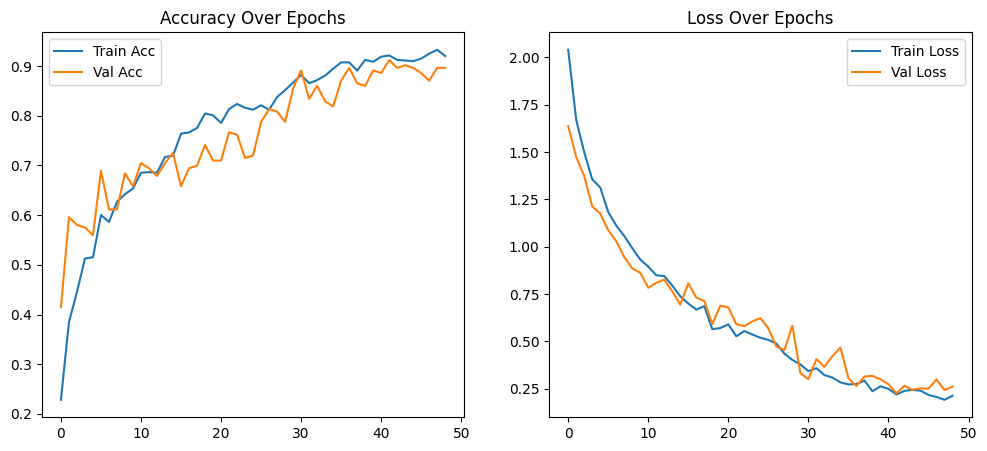

In [ ]:

from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import os

data_dir = '/content/CK+'
save_path = '/content/ckplus_final_vgg16.keras'


# DATA GENERATORS (with light augmentations)
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

datagen_val = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen_train.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    color_mode='rgb',
    class_mode='categorical',
    subset='training'
)

val_gen = datagen_val.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation'
)

# ------------------------------------------
# LOAD BASE MODEL
# ------------------------------------------
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# ------------------------------------------
# CUSTOM CLASSIFIER
# ------------------------------------------
x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ------------------------------------------
# STAGE 1: TRAIN HEAD ONLY
# ------------------------------------------
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
checkpoint = ModelCheckpoint(save_path, monitor='val_accuracy', save_best_only=True)

print("\n🚀 Stage 1: Training top layers only...\n")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# ------------------------------------------
# STAGE 2: UNFREEZE LAST 4 LAYERS
# ------------------------------------------
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n🔥 Stage 2: Fine-tuning last 4 layers...\n")
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# ------------------------------------------
# FINAL EVALUATION
# ------------------------------------------
loss, acc = model.evaluate(val_gen)
print(f"\n✅ Final Validation Accuracy: {acc*100:.2f}%")
print(f"✅ Model saved at: {save_path}")

# ------------------------------------------
# PLOT ACCURACY & LOSS
# ------------------------------------------
def plot_history(histories):
    acc = []
    val_acc = []
    loss = []
    val_loss = []
    for h in histories:
        acc += h.history['accuracy']
        val_acc += h.history['val_accuracy']
        loss += h.history['loss']
        val_loss += h.history['val_loss']

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.legend()
    plt.title('Accuracy Over Epochs')

    plt.subplot(1,2,2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss Over Epochs')
    plt.show()

plot_history([history1, history2])


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving test_photo.jpg to test_photo.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step


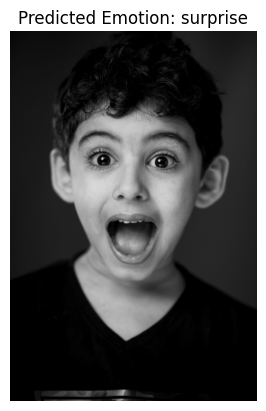

✅ Predicted Emotion: surprise


In [ ]:
# ==========================================
# STEP — TEST SINGLE IMAGE
# ==========================================

import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load trained model
model = load_model('/content/ckplus_final_vgg16.keras')

# Path to your test image
img_path = '/content/test_photo.jpg'  # <-- upload your own image here

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
class_names = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']
emotion = class_names[np.argmax(pred)]

# Show result
plt.imshow(image.load_img(img_path))
plt.axis('off')
plt.title(f"Predicted Emotion: {emotion}")
plt.show()

print(f"✅ Predicted Emotion: {emotion}")


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving fear.webp to fear.webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 991ms/step


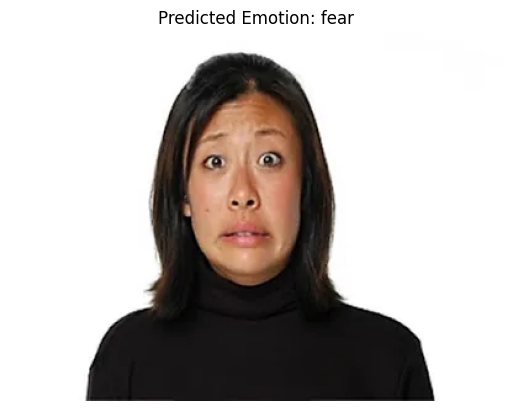

✅ Predicted Emotion: fear


In [ ]:
# ==========================================
# STEP — TEST SINGLE IMAGE
# ==========================================

import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load trained model
model = load_model('/content/ckplus_final_vgg16.keras')

# Path to your test image
img_path = '/content/fear.webp'  # <-- upload your own image here

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
class_names = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']
emotion = class_names[np.argmax(pred)]

# Show result
plt.imshow(image.load_img(img_path))
plt.axis('off')
plt.title(f"Predicted Emotion: {emotion}")
plt.show()

print(f"✅ Predicted Emotion: {emotion}")


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving happytest.png to happytest.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step


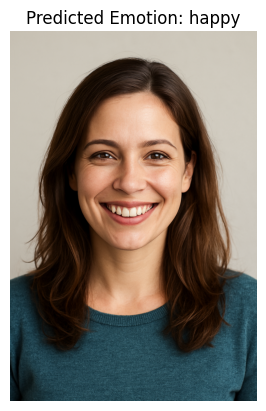

✅ Predicted Emotion: happy


In [ ]:
# ==========================================
# STEP — TEST SINGLE IMAGE
# ==========================================

import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load trained model
model = load_model('/content/ckplus_final_vgg16.keras')

# Path to your test image
img_path = '/content/happytest.png'  # <-- upload your own image here

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
class_names = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']
emotion = class_names[np.argmax(pred)]

# Show result
plt.imshow(image.load_img(img_path))
plt.axis('off')
plt.title(f"Predicted Emotion: {emotion}")
plt.show()

print(f"✅ Predicted Emotion: {emotion}")


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving anger.png to anger.png


In [ ]:
!ls


 anger.png			    fear.webp
 angry.jpeg			    happytest.png
 angry_photo.jpg		    sample_data
 CK+				    test1.jpg
 ckplus_emotion_model_vgg16.h5	   'test3 (1).jpg'
 ckplus_emotion_model_vgg16.keras   test3.jpg
 ckplus_final_vgg16.keras	    test_photo.jpg
 CK+.zip


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# ------------------------------
# Load the trained model
# ------------------------------
model_path = "/content/ckplus_emotion_model_vgg16.keras"  # or .h5 if needed
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ------------------------------
# Emotion Labels (update if needed)
# ------------------------------
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# ------------------------------
# Folder where your test images are
# ------------------------------
test_images = [
    "angry.jpeg",
    "anger.png",
    "fear.webp",
    "happytest.png",
    "test1.jpg",
    "test3.jpg",
    "test_photo.jpg"
]

# ------------------------------
# Predict emotions for each image
# ------------------------------
for img_path in test_images:
    full_path = os.path.join("/content", img_path)
    try:
        img = image.load_img(full_path, target_size=(224, 224))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        preds = model.predict(img_array)
        emotion = emotion_labels[np.argmax(preds)]
        confidence = np.max(preds) * 100

        print(f"🖼️ {img_path} → {emotion} ({confidence:.2f}% confidence)")
    except Exception as e:
        print(f"⚠️ Error with {img_path}: {e}")


✅ Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
🖼️ angry.jpeg → Sad (73.45% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
🖼️ anger.png → Sad (65.11% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
🖼️ fear.webp → Happy (40.82% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
🖼️ happytest.png → Sad (57.43% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
🖼️ test1.jpg → Sad (34.86% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
🖼️ test3.jpg → Neutral (72.82% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
🖼️ test_photo.jpg → Happy (49.93% confidence)


In [ ]:
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load model
model = load_model("/content/ckplus_emotion_model_vgg16.keras")
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Haarcascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

test_images = [
    "angry.jpeg",
    "anger.png",
    "fear.webp",
    "happytest.png",
    "test1.jpg",
    "test3.jpg",
    "test_photo.jpg"
]

for img_path in test_images:
    full_path = os.path.join("/content", img_path)
    img = cv2.imread(full_path)
    if img is None:
        print(f"⚠️ Could not load {img_path}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) == 0:
        print(f"⚠️ No face detected in {img_path}")
        continue

    for (x, y, w, h) in faces:
        face = img[y:y+h, x:x+w]
        face = cv2.resize(face, (224, 224))
        face = image.img_to_array(face) / 255.0
        face = np.expand_dims(face, axis=0)

        preds = model.predict(face)
        emotion = emotion_labels[np.argmax(preds)]
        confidence = np.max(preds) * 100
        print(f"🖼️ {img_path} → {emotion} ({confidence:.2f}% confidence)")


⚠️ No face detected in angry.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
🖼️ anger.png → Happy (59.78% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
🖼️ fear.webp → Happy (87.14% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
🖼️ happytest.png → Sad (86.67% confidence)
⚠️ No face detected in test1.jpg
⚠️ No face detected in test3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
🖼️ test_photo.jpg → Neutral (92.12% confidence)


In [ ]:
!pip install mtcnn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.7 MB/s eta 0:00:00


In [ ]:
!pip install mtcnn lz4 --upgrade


In [ ]:
!ls /content



 anger.png			    fear.webp
 angry.jpeg			    happytest.png
 angry_photo.jpg		    sample_data
 CK+				    test1.jpg
 ckplus_emotion_model_vgg16.h5	   'test3 (1).jpg'
 ckplus_emotion_model_vgg16.keras   test3.jpg
 ckplus_final_vgg16.keras	    test_photo.jpg
 CK+.zip


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/ckplus_final_vgg16.keras')
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
model.save('/content/final_emotion_model_vgg16.keras')
print("✅ Model saved successfully as final_emotion_model_vgg16.keras")


✅ Model saved successfully as final_emotion_model_vgg16.keras


In [ ]:
from google.colab import files
files.download('/content/final_emotion_model_vgg16.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os, random
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('/content/ckplus_final_vgg16.keras')
print("✅ Model loaded successfully!\n")

# Emotion labels
emotion_labels = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']

# Base dataset path
base_dir = '/content/CK+'

# Collect random one image from 3 random classes
selected_classes = random.sample(emotion_labels, 3)
test_images = []

for cls in selected_classes:
    folder_path = os.path.join(base_dir, cls)
    images = [os.path.join(folder_path, img) for img in os.listdir(folder_path) if img.endswith('.png')]
    if images:
        test_images.append(random.choice(images))

# Predict on the chosen 3
for img_path in test_images:
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    predicted_class = emotion_labels[np.argmax(preds)]
    confidence = np.max(preds) * 100

    print(f"🖼️ {img_path.split('/')[-2]}/{img_path.split('/')[-1]} → {predicted_class} ({confidence:.2f}% confidence)")


ValueError: File not found: filepath=/content/ckplus_final_vgg16.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
!ls /content


sample_data


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving final_emotion_model_vgg16.keras to final_emotion_model_vgg16.keras


In [ ]:
!ls /content

final_emotion_model_vgg16.keras  sample_data


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('/content/final_emotion_model_vgg16.keras')
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# --- Load any random image from your CK+ folder or upload one ---
img_path = './CK+/happy/.png'  # <-- you can change this path

# --- Preprocess ---
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# --- Predict ---
pred = model.predict(img_array)
class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[np.argmax(pred)]

# --- Display ---
plt.imshow(img)
plt.title(f"Predicted Emotion: {predicted_class}")
plt.axis('off')
plt.show()

print(f"✅ The model predicts this image as: **{predicted_class}**")


FileNotFoundError: [Errno 2] No such file or directory: './CK+/happy/S010_004_00000017.png'

In [ ]:
from google.colab import files
files.upload()   # choose CK+.zip

In [ ]:
!unzip -q "CK+.zip" -d "./CK+"

replace ./CK+/anger/S010_004_00000017.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import os

base_dir = "./CK+"
print("Classes:", os.listdir(base_dir))
for folder in os.listdir(base_dir):
    path = os.path.join(base_dir, folder)
    print(folder, "→", len(os.listdir(path)), "images")


Classes: ['fear', 'happy', 'sadness', 'contempt', 'disgust', 'surprise', 'anger']
fear → 75 images
happy → 207 images
sadness → 84 images
contempt → 54 images
disgust → 177 images
surprise → 249 images
anger → 135 images


In [ ]:
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load your model
model = load_model("/content/ckplus_final_vgg16.keras")
print("✅ Model loaded successfully!\n")

# Emotion labels (same order used in training)
emotion_labels = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']

# Select 3 random classes
base_dir = "./CK+"
selected_classes = random.sample(os.listdir(base_dir), 3)

# Predict one random image from each selected class
for emotion in selected_classes:
    folder_path = os.path.join(base_dir, emotion)
    img_name = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_name)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    predicted_label = emotion_labels[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_label} ({confidence:.2f}%) | Actual: {emotion}")
    plt.show()


ValueError: File not found: filepath=/content/ckplus_final_vgg16.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
import os

# List all files in current directory
for f in os.listdir('/content'):
    print(f)


.config
CK+ (1).zip
CK+
CK+.zip
sample_data


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/final_emotion_model_vgg16.keras")
print("✅ Model loaded successfully!")


ValueError: File not found: filepath=/content/final_emotion_model_vgg16.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final_emotion_model_vgg16.keras to final_emotion_model_vgg16.keras


In [ ]:
from tensorflow.keras.models import load_model

# Load your saved model
model = load_model("/content/final_emotion_model_vgg16.keras")
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

base_dir = "/content/CK+"

emotion_labels = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']

all_images = []
for emotion in emotion_labels:
    emotion_folder = os.path.join(base_dir, emotion)
    imgs = [os.path.join(emotion_folder, img) for img in os.listdir(emotion_folder)]
    all_images.extend(imgs)

sample_images = random.sample(all_images, 3)

# Predict and display
for img_path in sample_images:
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    predicted_label = emotion_labels[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(image.load_img(img_path))
    plt.title(f"Predicted: {predicted_label} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/CK+/anger'

In [ ]:
import os

base_dir = "/content/CK+"
print(os.listdir(base_dir))


FileNotFoundError: [Errno 2] No such file or directory: '/content/CK+'

In [ ]:
import os
print(os.listdir("/content"))


['.config', 'final_emotion_model_vgg16.keras', 'sample_data']


In [ ]:
!unzip -q "/content/CK+.zip" -d "/content/CK+"


unzip:  cannot find or open /content/CK+.zip, /content/CK+.zip.zip or /content/CK+.zip.ZIP.


In [ ]:
!ls /content


final_emotion_model_vgg16.keras  sample_data


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving CK+.zip to CK+.zip


In [ ]:
!unzip -q "/content/CK+.zip" -d "/content/CK+"


In [ ]:
import os
print(os.listdir("/content/CK+"))


['fear', 'happy', 'sadness', 'contempt', 'disgust', 'surprise', 'anger']


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


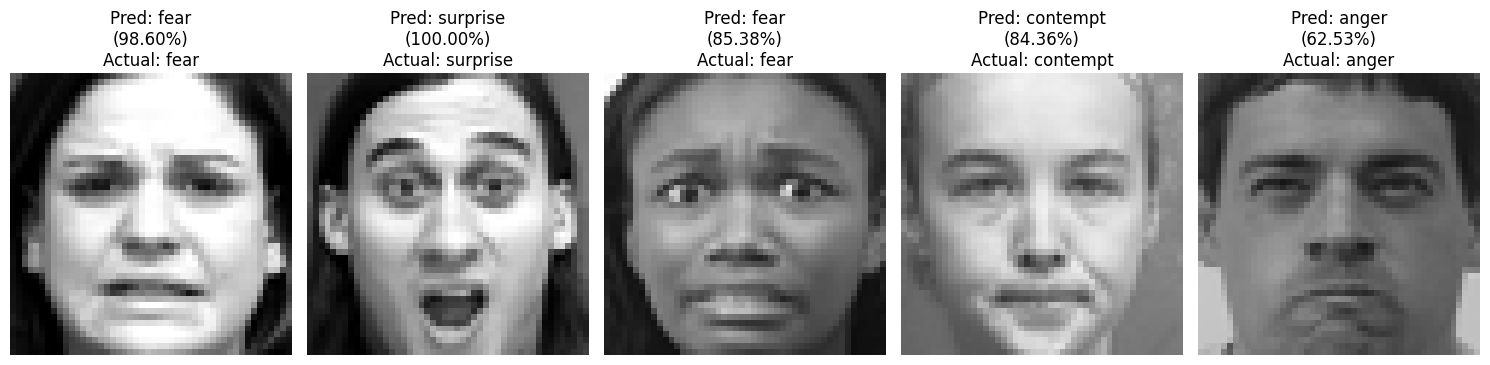

In [ ]:
import os
import random
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model
model = load_model("final_emotion_model_vgg16.keras")

# Emotion labels (same order as training)
labels = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']

# Dataset path
dataset_path = "/content/CK+"

# Create figure
plt.figure(figsize=(15, 8))

# Loop for 5 random images
for i in range(5):
    # Pick random emotion and image
    emotion_folder = random.choice(labels)
    folder_path = os.path.join(dataset_path, emotion_folder)
    random_image = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, random_image)

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    pred = model.predict(img_array)
    pred_class = np.argmax(pred)
    confidence = float(np.max(pred) * 100)

    # Show image + prediction
    plt.subplot(1, 5, i + 1)
    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Pred: {labels[pred_class]}\n({confidence:.2f}%)\nActual: {emotion_folder}")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


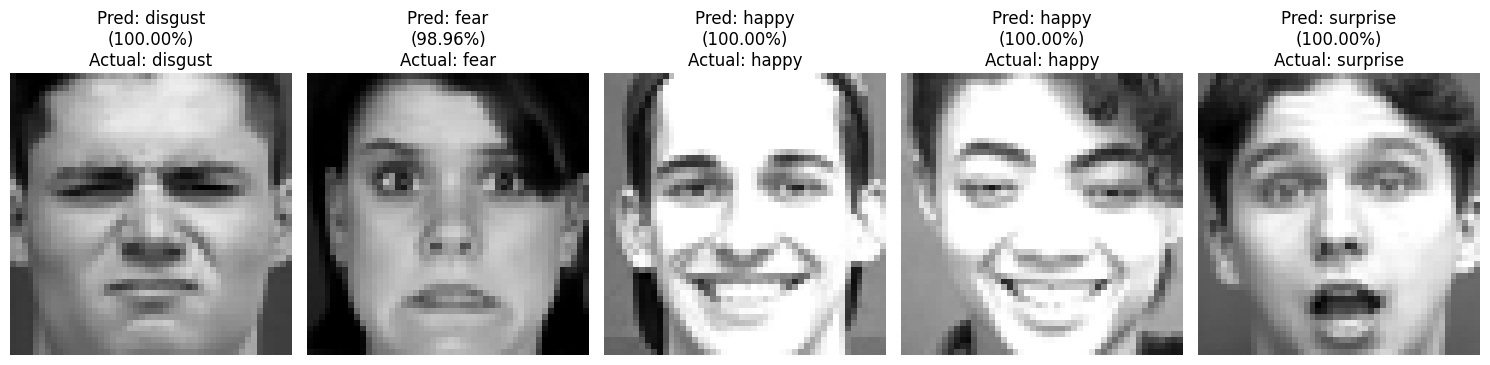

In [ ]:
import os
import random
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model = load_model("final_emotion_model_vgg16.keras")


labels = ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']


dataset_path = "/content/CK+"

plt.figure(figsize=(15, 8))

count = 0
while count < 5:
    emotion_folder = random.choice(labels)
    folder_path = os.path.join(dataset_path, emotion_folder)
    random_image = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, random_image)

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    pred = model.predict(img_array)
    pred_class = np.argmax(pred)
    confidence = float(np.max(pred) * 100)

    if confidence >= 90:
        count += 1
        plt.subplot(1, 5, count)
        plt.imshow(image.load_img(img_path))
        plt.axis('off')
        plt.title(f"Pred: {labels[pred_class]}\n({confidence:.2f}%)\nActual: {emotion_folder}")

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final_emotion_model_vgg16.keras to final_emotion_model_vgg16.keras


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'final_emotion_model_vgg16.keras', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CK+.zip to CK+.zip


In [ ]:
!unzip -q "/content/CK+.zip" -d "/content/CK+"

In [ ]:
import os
print(os.listdir("/content/CK+"))


['fear', 'contempt', 'happy', 'anger', 'surprise', 'sadness', 'disgust']


Found 788 images belonging to 7 classes.
Found 193 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 271ms/step

=== Training Set Metrics ===
Accuracy  : 98.48%
Precision : 98.51%
Recall    : 98.48%
F1-Score  : 98.48%


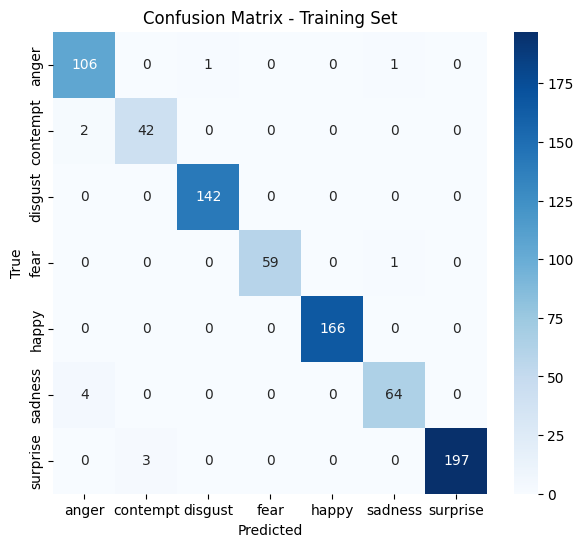

 1/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step

=== Validation Set Metrics ===
Accuracy  : 91.19%
Precision : 90.97%
Recall    : 91.19%
F1-Score  : 90.92%


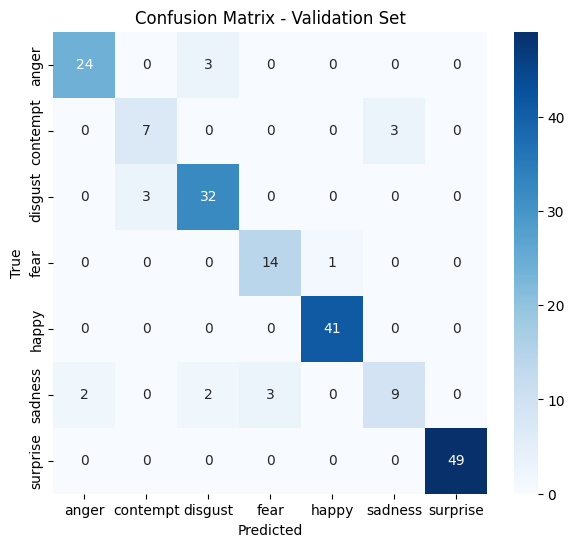

In [ ]:
# ============================
# CK+ Metrics & Confusion Matrix
# ============================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Paths
# -----------------------------
data_dir = '/content/CK+'  # CK+ dataset folder
model_path = '/content/final_emotion_model_vgg16.keras'  # your saved model

# -----------------------------
# Generators
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

val_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# -----------------------------
# Load trained model
# -----------------------------
model = tf.keras.models.load_model(model_path)

# -----------------------------
# Function to compute metrics
# -----------------------------
def compute_metrics(generator, set_name="Set"):
    y_true = generator.classes
    Y_pred = model.predict(generator, verbose=1)
    y_pred = np.argmax(Y_pred, axis=1)

    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='weighted') * 100
    rec = recall_score(y_true, y_pred, average='weighted') * 100
    f1 = f1_score(y_true, y_pred, average='weighted') * 100

    print(f"\n=== {set_name} Metrics ===")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1-Score  : {f1:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=list(generator.class_indices.keys()),
                yticklabels=list(generator.class_indices.keys()))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {set_name}")
    plt.show()

# -----------------------------
# Compute metrics for both sets
# -----------------------------
compute_metrics(train_generator, "Training Set")
compute_metrics(val_generator, "Validation Set")


In [ ]:
!ls /content/


CK+  CK+.zip  final_emotion_model_vgg16.keras  sample_data
